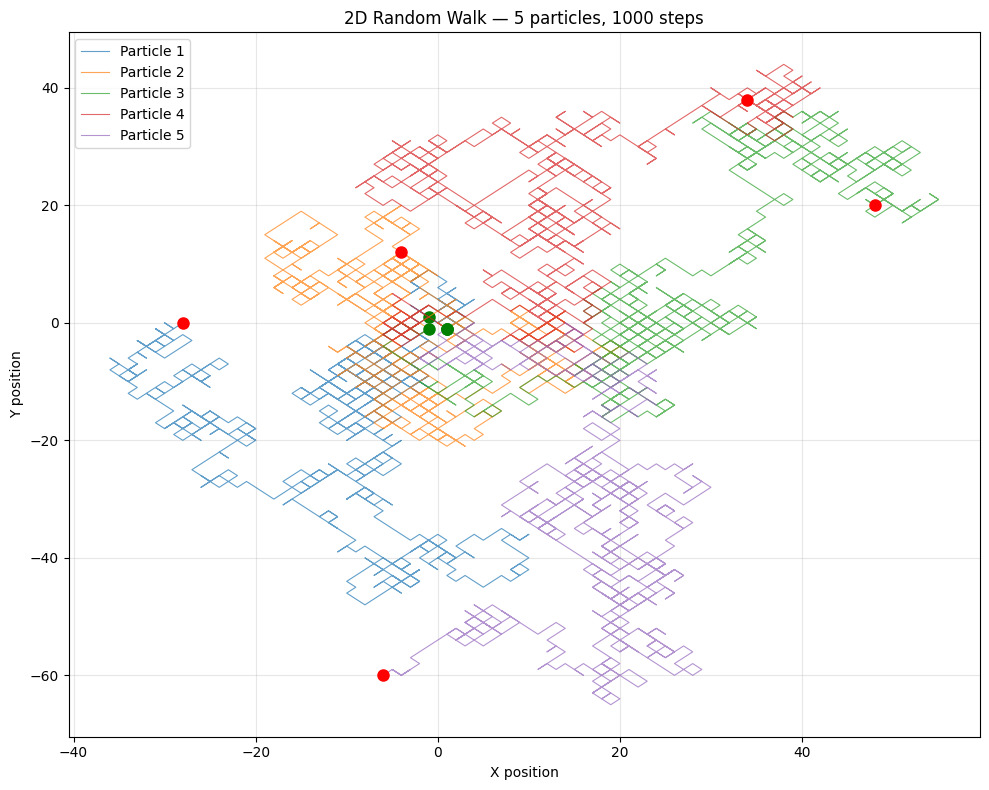

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r'C:/Users/Giannis/.vscode/02_monte_carlo_simulation_toolkit')

# Parameters
n_steps = 1000
n_walkers = 5  # simulate 5 independent particles

plt.figure(figsize=(10, 8))

for i in range(n_walkers):
    # Random steps in x and y (-1 or +1)
    steps_x = np.random.choice([-1, 1], n_steps)
    steps_y = np.random.choice([-1, 1], n_steps)
    
    # Cumulative sum = actual position over time
    x = np.cumsum(steps_x)
    y = np.cumsum(steps_y)
    
    plt.plot(x, y, alpha=0.7, linewidth=0.8, label=f'Particle {i+1}')
    plt.plot(x[0], y[0], 'go', markersize=8)   # start = green
    plt.plot(x[-1], y[-1], 'ro', markersize=8)  # end = red

plt.title(f'2D Random Walk — {n_walkers} particles, {n_steps} steps')
plt.xlabel('X position')
plt.ylabel('Y position')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/03_random_walk_paths.png', bbox_inches='tight')
plt.show()

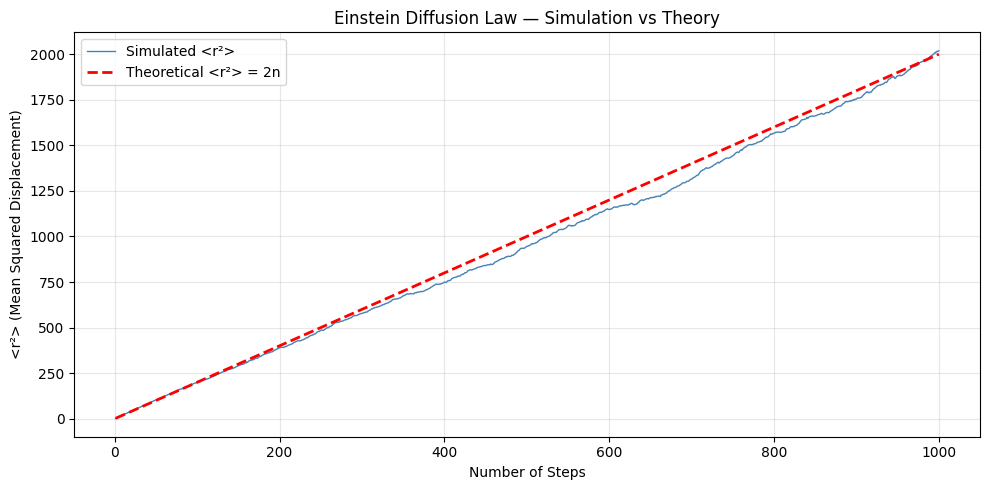

In [2]:
n_steps = 1000
n_walkers = 1000  # more walkers = smoother simulation line

displacements = []

for _ in range(n_walkers):
    steps_x = np.random.choice([-1, 1], n_steps)
    steps_y = np.random.choice([-1, 1], n_steps)
    x = np.cumsum(steps_x)
    y = np.cumsum(steps_y)
    r_squared = x**2 + y**2
    displacements.append(r_squared)

mean_r_squared = np.mean(displacements, axis=0)
steps = np.arange(1, n_steps + 1)

plt.figure(figsize=(10, 5))
plt.plot(steps, mean_r_squared, color='steelblue',
         linewidth=1, label='Simulated <r²>')
plt.plot(steps, 2 * steps, 'r--', linewidth=2,
         label='Theoretical <r²> = 2n')
plt.xlabel('Number of Steps')
plt.ylabel('<r²> (Mean Squared Displacement)')
plt.title('Einstein Diffusion Law — Simulation vs Theory')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/03_diffusion_law.png', bbox_inches='tight')
plt.show()